In [5]:
import pandas as pd

In [6]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
df.shape

(1338, 7)

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
df.columns[df.isnull().any()]

Index([], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df=df.drop(["smoker"],axis=1)
df

,age,sex,bmi,children,region,charges
0,19,female,27.900,0,southwest,16884.92400
1,18,male,33.770,1,southeast,1725.55230
2,28,male,33.000,3,southeast,4449.46200
3,33,male,22.705,0,northwest,21984.47061
4,32,male,28.880,0,northwest,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,northwest,10600.54830
1334,18,female,31.920,0,northeast,2205.98080
1335,18,female,36.850,0,southeast,1629.83350
1336,21,female,25.800,0,southwest,2007.94500


In [14]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   region    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


In [16]:
k=pd.get_dummies(df["sex"])
k

,female,male
0,True,False
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
1333,False,True
1334,True,False
1335,True,False
1336,True,False


In [17]:
df=pd.concat([df,k],axis=1)
df

,age,sex,bmi,children,region,charges,female,male
0,19,female,27.900,0,southwest,16884.92400,True,False
1,18,male,33.770,1,southeast,1725.55230,False,True
2,28,male,33.000,3,southeast,4449.46200,False,True
3,33,male,22.705,0,northwest,21984.47061,False,True
4,32,male,28.880,0,northwest,3866.85520,False,True
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,northwest,10600.54830,False,True
1334,18,female,31.920,0,northeast,2205.98080,True,False
1335,18,female,36.850,0,southeast,1629.83350,True,False
1336,21,female,25.800,0,southwest,2007.94500,True,False


In [18]:
df["charges"] = df["charges"].fillna(df["charges"].mean())
df["charges"]

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [19]:
df["age"] = df["age"].fillna(df["age"].mean())
df["age"]

0       19
1       18
2       28
3       33
4       32
        ..
1333    50
1334    18
1335    18
1336    21
1337    61
Name: age, Length: 1338, dtype: int64

In [20]:
#pip install scikit-learn


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x=df[["charges"]]
y=df["age"]
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)
x_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
701,9541.69555
672,4399.73100
1163,2200.83085
1103,11363.28320


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
from sklearn.metrics import r2_score

In [25]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = lr.predict(x_test)
y_pred

array([37.75448787, 36.46668738, 44.571269  , 37.82416017, 46.05998151,
       36.21878242, 35.40393172, 39.47771234, 35.9480659 , 38.14840955,
       40.84157287, 37.13521285, 36.02042056, 50.23739394, 51.08711497,
       49.58102136, 37.99225424, 49.1657333 , 37.46411968, 42.02569078,
       36.40198233, 37.19745815, 35.11387712, 35.61874481, 38.42502485,
       38.37056933, 38.95019887, 41.02534525, 37.96360478, 35.07183887,
       40.02285695, 38.68004446, 35.37132768, 36.60859354, 35.66896035,
       37.19978351, 35.56577543, 37.16250734, 42.73760226, 47.73045841,
       36.26983034, 35.58109927, 38.62328474, 38.77516471, 36.33794538,
       38.84551422, 35.89659407, 36.17006931, 48.88096831, 36.19417308,
       39.36879296, 35.26989209, 44.28350228, 35.26635145, 38.25950226,
       43.22459862, 35.91857814, 47.74298276, 38.68190303, 38.24961822,
       39.36668587, 36.29200949, 44.10312854, 37.39134449, 42.453929  ,
       36.08315453, 40.73474946, 43.44675742, 35.90142544, 35.25

In [27]:
lr.coef_

array([0.00033687])

In [28]:
lr.intercept_

np.float64(34.69067336281089)

In [29]:
r2_score(y_test,y_pred)

0.10356424042347923

In [31]:
import numpy as np

a=np.array(5.7).reshape(-1,1)
b=lr.predict(a)

b

C:\Users\karth\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([34.6925935])

In [32]:
import matplotlib.pyplot as plt

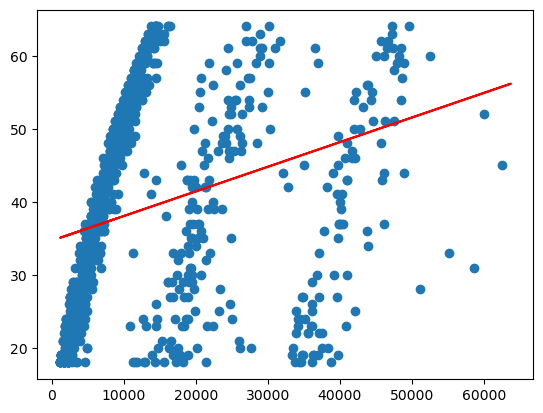

In [33]:
plt.scatter(x_train,y_train)
plt.plot(x_test,y_pred,color="red")
plt.show()